# 2. Exploratory Data Analysis

EDA on wrangled TED awards data (`data/interim/ted_awards_wrangled.csv`).

## Objectives
- Understand data structure, coverage, and quality
- Quantify missingness (kept intentionally after wrangling)
- Analyze `NUMBER_OFFERS` behavior and modeling bins
- Inspect temporal and categorical patterns relevant for feature engineering

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the notebook's own path (injected by VS Code) to find the project root
nb_file = globals().get("__vsc_ipynb_file__", "")
print("Notebook path:", nb_file)
ROOT = Path(nb_file).parent.parent
print("ROOT:", ROOT)
DATA_PATH = ROOT / "data" / "interim" / "ted_awards_wrangled.csv"

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

ModuleNotFoundError: No module named 'numpy'

In [7]:
# Schema inspection
print(df.dtypes.value_counts())
print("\nColumns:", len(df.columns))
df.info()

str        47
float64    19
int64       9
Name: count, dtype: int64

Columns: 75
<class 'pandas.DataFrame'>
RangeIndex: 3392 entries, 0 to 3391
Data columns (total 75 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_NOTICE_CAN                 3392 non-null   int64  
 1   TED_NOTICE_URL                3392 non-null   str    
 2   YEAR                          3392 non-null   int64  
 3   ID_TYPE                       3392 non-null   int64  
 4   DT_DISPATCH                   3392 non-null   int64  
 5   XSD_VERSION                   3392 non-null   str    
 6   CANCELLED                     3392 non-null   int64  
 7   CORRECTIONS                   3392 non-null   int64  
 8   B_MULTIPLE_CAE                3369 non-null   str    
 9   CAE_NAME                      3392 non-null   str    
 10  CAE_NATIONALID                3356 non-null   str    
 11  CAE_ADDRESS                   3330 non-null   str  

In [8]:
# Quick data-quality snapshot
quality_snapshot = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "total_missing_cells": int(df.isna().sum().sum()),
        "missing_cell_ratio_pct": round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
    }
)
quality_snapshot

rows                       3392.00
columns                      75.00
duplicate_rows                0.00
total_missing_cells       60481.00
missing_cell_ratio_pct       23.77
dtype: float64

In [20]:
# Missing values profile (counts + percentages of rows)
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct_rows = (missing_count / len(df) * 100).round(2)

missing_profile = pd.DataFrame(
    {
        "missing_count": missing_count,
        "missing_pct_rows": missing_pct_rows,
    }
).sort_values("missing_count", ascending=False)

print("Interpretation: missing_pct_rows is the % of dataset rows where the column is null.")
missing_profile[missing_profile["missing_count"] > 0].head(30)

Interpretation: missing_pct_rows is the % of dataset rows where the column is null.


,missing_count,missing_pct_rows
ISO_COUNTRY_CODE_ALL,3392,100.00
EU_INST_CODE,3392,100.00
B_ACCELERATED,3384,99.76
INFO_ON_NON_AWARD,3063,90.30
ID_LOT_AWARDED,2993,88.24
ID_LOT,2765,81.52
AWARD_EST_VALUE_EURO,2691,79.33
NUMBER_TENDERS_NON_EU,2629,77.51
NUMBER_TENDERS_OTHER_EU,2491,73.44
NUMBER_TENDERS_SME,2338,68.93


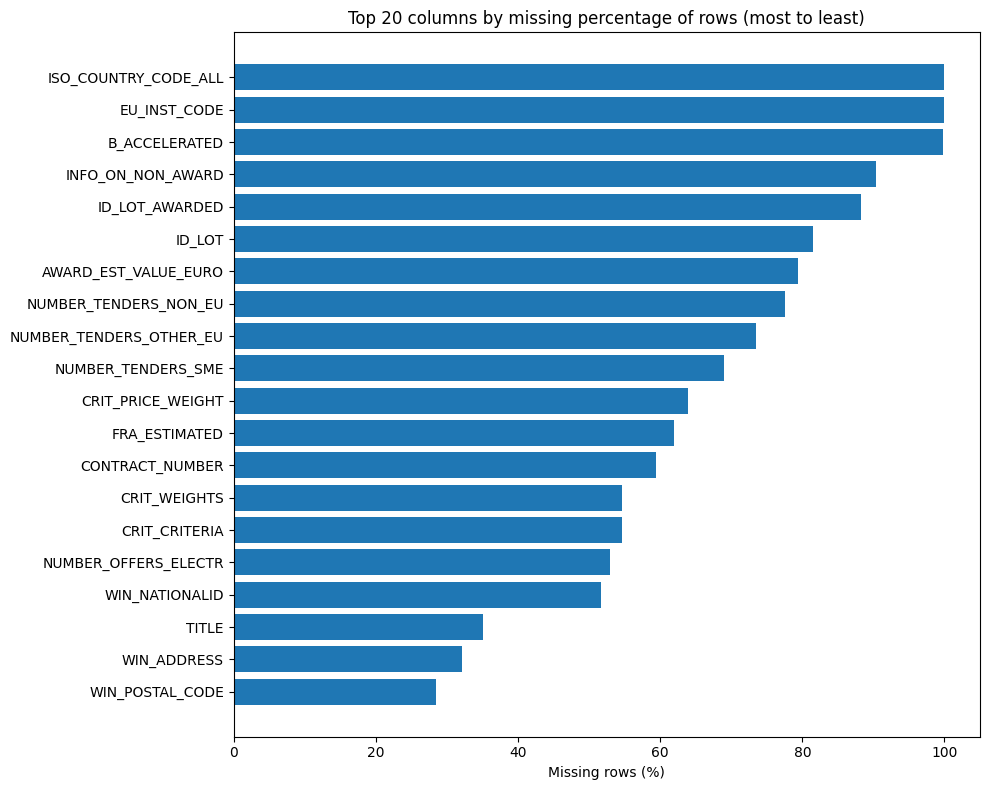

In [21]:
# Missingness chart (top 20 columns, most -> least)
plot_df = missing_profile[missing_profile["missing_count"] > 0].head(20)

plt.figure(figsize=(10, 8))
plt.barh(plot_df.index.astype(str), plot_df["missing_pct_rows"])
plt.gca().invert_yaxis()
plt.xlabel("Missing rows (%)")
plt.title("Top 20 columns by missing percentage of rows (most to least)")
plt.tight_layout()
plt.show()

In [19]:
# Target distribution: raw NUMBER_OFFERS
number_offers = pd.to_numeric(df.get("NUMBER_OFFERS"), errors="coerce")

missing_offers = int(number_offers.isna().sum())
non_missing_offers = int(number_offers.notna().sum())

print("Rows with missing NUMBER_OFFERS:", missing_offers)
print("Rows with observed NUMBER_OFFERS:", non_missing_offers)
print("Observed coverage (% of rows):", round(non_missing_offers / len(df) * 100, 2))
print("Missing coverage (% of rows):", round(missing_offers / len(df) * 100, 2))

number_offers.describe()

Rows with missing NUMBER_OFFERS: 825
Rows with observed NUMBER_OFFERS: 2567
Observed coverage (% of rows): 75.68
Missing coverage (% of rows): 24.32


count    2567.000000
mean        5.303467
std         5.158690
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        42.000000
Name: NUMBER_OFFERS, dtype: float64

In [12]:
# Target class-bin preview used in modeling
bins = pd.cut(
    number_offers,
    bins=[-float("inf"), 1, 4, 9, float("inf")],
    labels=["1", "2-4", "5-9", "10+"],
)

bin_counts = bins.value_counts(dropna=False).sort_index()
bin_pct = (bin_counts / len(df) * 100).round(2)

pd.DataFrame({"count": bin_counts, "pct_of_all_rows": bin_pct})

,count,pct_of_all_rows
NUMBER_OFFERS,,
1,214,6.31
2-4,1323,39.00
5-9,756,22.29
10+,274,8.08
NaN,825,24.32


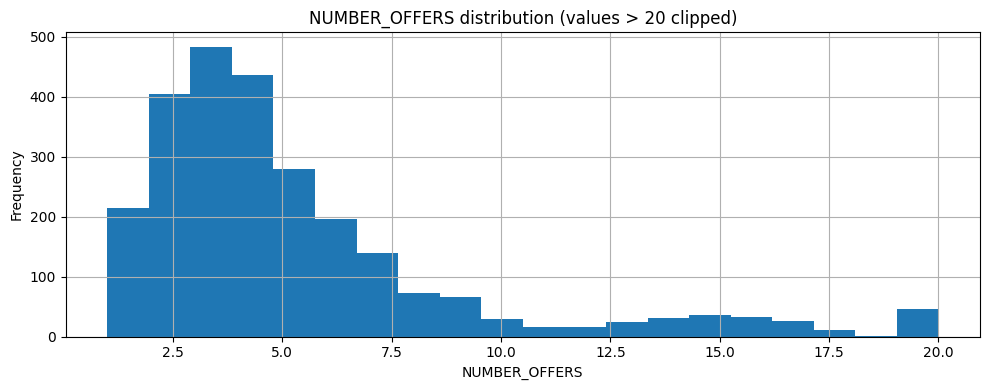

In [13]:
# Distribution chart for non-missing NUMBER_OFFERS (capped for readability)
plt.figure(figsize=(10, 4))
number_offers.dropna().clip(upper=20).hist(bins=20)
plt.title("NUMBER_OFFERS distribution (values > 20 clipped)")
plt.xlabel("NUMBER_OFFERS")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

,rows,non_missing_number_offers,median_number_offers,mean_number_offers
YEAR,,,,
2018,643,506,4.0,4.703557
2019,560,412,3.0,5.575243
2020,519,416,5.0,6.468750
2021,676,500,4.0,5.046000
2022,591,413,4.0,5.329298
2023,403,320,4.0,4.756250


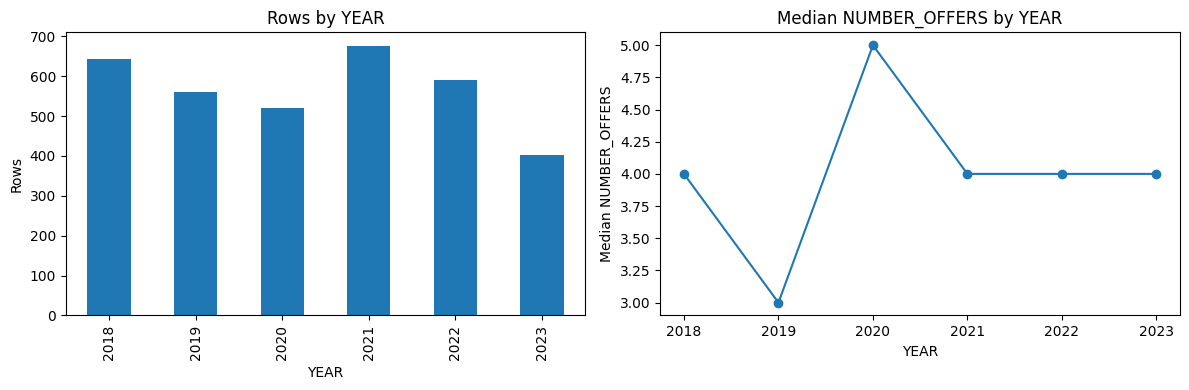

In [14]:
# Year-level coverage and target trend
if "YEAR" in df.columns:
    year_df = pd.DataFrame(
        {
            "rows": df.groupby("YEAR").size(),
            "non_missing_number_offers": number_offers.groupby(df["YEAR"]).apply(lambda s: s.notna().sum()),
            "median_number_offers": number_offers.groupby(df["YEAR"]).median(),
            "mean_number_offers": number_offers.groupby(df["YEAR"]).mean(),
        }
    ).sort_index()
    display(year_df)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    year_df["rows"].plot(kind="bar", ax=ax[0], title="Rows by YEAR")
    year_df["median_number_offers"].plot(kind="line", marker="o", ax=ax[1], title="Median NUMBER_OFFERS by YEAR")
    ax[0].set_ylabel("Rows")
    ax[1].set_ylabel("Median NUMBER_OFFERS")
    plt.tight_layout()
    plt.show()
else:
    print("YEAR column not found; skipping year-level analysis.")

In [15]:
# Categorical signal scan: top categories in selected columns
candidate_cols = [
    "CAE_NAME",
    "ISO_COUNTRY_CODE",
    "WIN_COUNTRY_CODE",
    "TYPE_CONTRACT",
    "TYPE_OF_PROCEDURE",
]

available_cols = [col for col in candidate_cols if col in df.columns]

for col in available_cols:
    print(f"\n--- {col} (top 10 incl. missing) ---")
    print(df[col].fillna("<MISSING>").value_counts().head(10))


--- CAE_NAME (top 10 incl. missing) ---
CAE_NAME
Statens vegvesen               443
Bane NOR SF                    145
Agder fylkeskommune            132
Politiets fellestjenester      103
Sykehusinnkjøp HF               95
Statens vegvesen Region sør     79
Vestland fylkeskommune          66
Rogaland Fylkeskommune          65
Statsbygg                       59
AVINOR AS                       55
Name: count, dtype: int64

--- ISO_COUNTRY_CODE (top 10 incl. missing) ---
ISO_COUNTRY_CODE
NO    3392
Name: count, dtype: int64

--- WIN_COUNTRY_CODE (top 10 incl. missing) ---
WIN_COUNTRY_CODE
NO                             2494
<MISSING>                       797
NO---NO---NO                     27
NO---NO                          19
DK                                8
FI                                8
SE                                6
NO---NO---NO---NO---NO            4
ES                                4
NO---NO---NO---NO---NO---NO       3
Name: count, dtype: int64


In [16]:
# Numeric feature summary for feature engineering decisions
numeric_df = df.select_dtypes(include=["number"])
print("Numeric columns:", numeric_df.shape[1])

numeric_df.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head(20)

Numeric columns: 28


,count,mean,std,min,25%,50%,75%,max
ID_NOTICE_CAN,3392.0,1.764656e+09,6.365358e+08,20184372.00,2.018340e+09,2.020325e+09,2.022151e+09,2.023791e+09
YEAR,3392.0,2.020360e+03,1.661353e+00,2018.00,2.019000e+03,2.020000e+03,2.022000e+03,2.023000e+03
ID_TYPE,3392.0,3.471993e+00,1.688455e+00,3.00,3.000000e+00,3.000000e+00,3.000000e+00,2.500000e+01
DT_DISPATCH,3392.0,4.413362e+04,6.129259e+02,43103.00,4.360000e+04,4.417450e+04,4.466350e+04,4.528200e+04
CANCELLED,3392.0,0.000000e+00,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
CORRECTIONS,3392.0,8.844340e-04,2.973066e-02,0.00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
ISO_COUNTRY_CODE_ALL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EU_INST_CODE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPV,3392.0,4.516911e+07,1.455793e+05,45000000.00,4.500000e+07,4.521422e+07,4.524400e+07,4.550000e+07
MAIN_CPV_CODE_GPA,2988.0,4.516557e+04,1.452485e+02,45000.00,4.500000e+04,4.521400e+04,4.523400e+04,4.550000e+04
